Contoh Soal Bayesian Optimization

In [109]:
import numpy as np
import matplotlib.pyplot as plt
from bayes_opt import BayesianOptimization

# Mendefinisi fungsi yang ingin dioptimalkan (fungsi black-box)
def fungsi_blackbox(x):
    return (-(x - 2)**2) + np.exp(-(x - 6)**2/10)

x = np.linspace(-20, 20, 500).reshape(-1,1)
y = fungsi_blackbox(x)

In [110]:
# Menentukan batas parameter
batas_parameter = {'x': (-8, 8)}

# Inisiasi Algoritma Bayesian Otimization
optimizer = BayesianOptimization(f=fungsi_blackbox,
                                 pbounds=batas_parameter,
                                 random_state=42)
optimizer.maximize(init_points=5,
                   n_iter=15)

print(optimizer.max)


|   iter    |  target   |     x     |
-------------------------------------
| 1         | -16.05727 | -2.007358 |
| 2         | -26.29548 | 7.2114289 |
| 3         | -2.338191 | 3.7119030 |
| 4         | -0.036058 | 1.5785357 |
| 5         | -56.30553 | -5.503701 |
| 6         | -3.959360 | 0.0033046 |
| 7         | -0.058086 | 2.6128514 |
| 8         | 0.2086963 | 2.0793211 |
| 9         | 0.1894199 | 1.9423906 |
| 10        | 0.1969318 | 2.1956117 |
| 11        | 0.2087220 | 2.0848633 |
| 12        | 0.2086761 | 2.0775842 |
| 13        | 0.2056174 | 2.1415284 |
| 14        | 0.2055516 | 2.0269161 |
| 15        | 0.2070668 | 2.1261468 |
| 16        | 0.2065707 | 2.0370685 |
| 17        | 0.2064997 | 2.1327530 |
| 18        | 0.2072407 | 2.0451454 |
| 19        | 0.2083166 | 2.0639187 |
| 20        | 0.2056904 | 2.1408536 |
{'target': 0.20872205770344768, 'params': {'x': 2.084863360664376}}


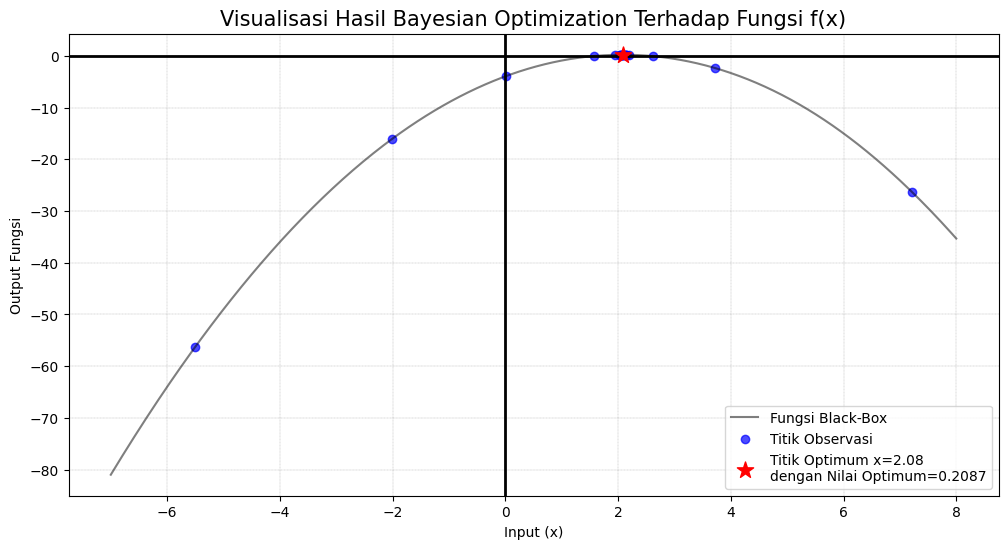

In [111]:
# Mengambil titik optimum hasil algoritma Bayesian Optimization
best_x = optimizer.max['params']['x']
best_y = optimizer.max['target']

# Mengambil semua titik yang diobservasi 
x_obs = [res['params']['x'] for res in optimizer.res]
y_obs = [res['target'] for res in optimizer.res]

# Visualisasi titik-titik observasi, titik optimum, dan fungsi asli
plt.figure(figsize=(12, 6))

# Visualisasi fungsi asli
x_plot = np.linspace(-7, 8, 500) 
y_plot = fungsi_blackbox(x_plot)
plt.plot(x_plot, y_plot, color='black', alpha=0.5, label='Fungsi Black-Box')

# Visualisasi sumbu dan grid
plt.axhline(0, color='black', linewidth=2) # sumbu y
plt.axvline(0, color='black', linewidth=2) # sumbu x
plt.grid(color='black', linestyle='--', linewidth=0.2, alpha=0.3) # grid

plt.scatter(x_obs, y_obs, color='blue', alpha=0.7, label='Titik Observasi') # Plot semua titik observasi
plt.scatter(best_x, best_y, color='red', marker='*', s=150, label=f'Titik Optimum x={best_x:.2f}\ndengan Nilai Optimum={best_y:.4f}', zorder=5) # Plot titik optimum

plt.title(f'Visualisasi Hasil Bayesian Optimization Terhadap Fungsi f(x)', fontsize=15)
plt.xlabel('Input (x)')
plt.ylabel('Output Fungsi')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()